<a href="https://colab.research.google.com/github/KavindaKGD/DL_Final_Assignment/blob/dev%2FMigara/Copy_of_LSTM_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
!nvidia-smi

Sat Oct 18 18:25:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             29W /   70W |     292MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [100]:
# Basic libraries
import os, glob, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import classification_report, confusion_matrix

In [102]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
!unzip -q "/content/drive/MyDrive/street_building_dataset.zip" -d "/content/dataset"

replace /content/dataset/street_building_dataset/test/buildings/20057.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [104]:
import os
for root, dirs, files in os.walk("/content/dataset/street_building_dataset"):
    print(root, "->", len(files), "files")

/content/dataset/street_building_dataset -> 0 files
/content/dataset/street_building_dataset/test -> 0 files
/content/dataset/street_building_dataset/test/buildings -> 437 files
/content/dataset/street_building_dataset/test/streets -> 501 files
/content/dataset/street_building_dataset/train -> 0 files
/content/dataset/street_building_dataset/train/buildings -> 2191 files
/content/dataset/street_building_dataset/train/streets -> 2382 files


In [105]:
DATA_ROOT = "/content/dataset/street_building_dataset"

In [106]:
from tensorflow.keras import layers

# Define a simple augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(factor=0.1)
])

In [107]:
from PIL import Image
import os

def remove_corrupt_images(directory):
    removed = 0
    for root, _, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except (IOError, SyntaxError):
                print("Removing:", path)
                os.remove(path)
                removed += 1
    print(f"Removed {removed} corrupt images")

remove_corrupt_images("/content/dataset/street_building_dataset/train")
remove_corrupt_images("/content/dataset/street_building_dataset/test")

Removed 0 corrupt images
Removed 0 corrupt images


In [108]:
import tensorflow as tf

IMG_H, IMG_W = 150, 150
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/street_building_dataset/train",
    labels="inferred",
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/street_building_dataset/test",
    labels="inferred",
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 4573 files belonging to 2 classes.
Found 938 files belonging to 2 classes.
Classes: ['buildings', 'streets']


In [109]:
AUTOTUNE = tf.data.AUTOTUNE

def color_to_seq(images, labels):
    # Apply augmentation only for training
    images = data_augmentation(images)
    images = tf.cast(images, tf.float32) / 255.0
    shape = tf.shape(images)
    images = tf.reshape(images, (shape[0], shape[1], shape[2]*3))  # (batch, 150, 450)
    return images, labels

train_ds = train_ds.map(color_to_seq).cache().prefetch(AUTOTUNE)

# For test data — no augmentation
def color_to_seq_test(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    shape = tf.shape(images)
    images = tf.reshape(images, (shape[0], shape[1], shape[2]*3))
    return images, labels

test_ds = test_ds.map(color_to_seq_test).cache().prefetch(AUTOTUNE)

In [110]:
from tensorflow.keras import layers, models, Input

timesteps = IMG_H
features = IMG_W * 3

inputs = Input(shape=(timesteps, features))
x = layers.LSTM(128)(inputs)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 150, 450)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,769 (1.16 MB)

 Trainable params: 304,769 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_lstm.keras", monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 28s 184ms/step - accuracy: 0.5136 - loss: 0.7071 - val_accuracy: 0.5458 - val_loss: 0.6876
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5339 - loss: 0.6922 - val_accuracy: 0.5768 - val_loss: 0.6836
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5380 - loss: 0.6912 - val_accuracy: 0.5682 - val_loss: 0.6813
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5426 - loss: 0.6900 - val_accuracy: 0.5991 - val_loss: 0.6780
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5783 - loss: 0.6841 - val_accuracy: 0.5650 - val_loss: 0.6796
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5525 - loss: 0.6826 - val_accuracy: 0.6109 - val_loss: 0.6755
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5724 - loss: 0.6784 - val_accuracy: 0.6151 - val_loss: 0.6682
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5872 - loss: 0.6726 - val_ac

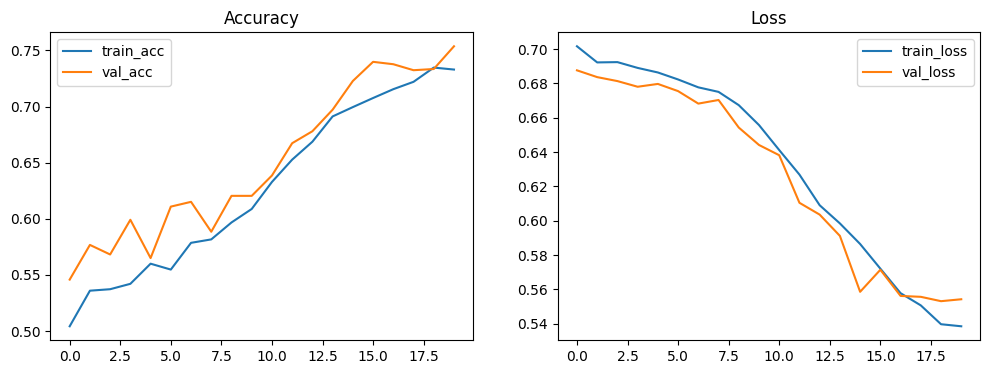

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.show()

In [113]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.3f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6696 - loss: 0.5954
Test Accuracy: 0.733


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6696 - loss: 0.5954

Test Accuracy: 0.733
Test (Validation) Loss: 0.553
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7567 - loss: 0.5242
Training Accuracy: 0.767
Training Loss: 0.522
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.77      0.61      0.68       437
     streets       0.71      0.84      0.77       501

    accuracy                           0.73       938
   macro avg       0.74      0.73      0.73       938
weighted avg       0.74      0.73      0.73       938



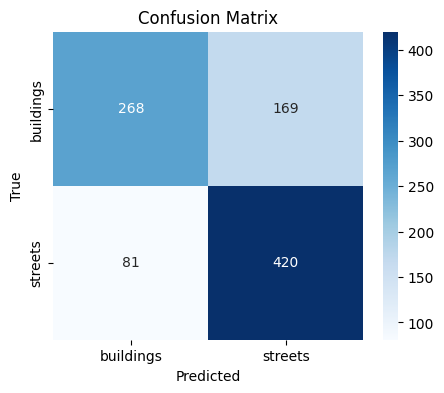

In [114]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.3f}")
print(f"Test (Validation) Loss: {test_loss:.3f}")

train_loss, train_acc = model.evaluate(train_ds)
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Training Loss: {train_loss:.3f}")

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = (y_prob.flatten() >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [115]:
model.save("/content/drive/MyDrive/best_lstm_street_building.keras")

In [116]:
!unzip -q "/content/dataset/pred.zip" -d "/content/dataset/pred"

replace /content/dataset/pred/pred/20057.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [117]:
pred_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/pred",
    labels=None,
    image_size=(IMG_H, IMG_W),
    batch_size=32,
    shuffle=False
)

# Apply same preprocessing as training
def color_to_seq_pred(images):
    images = tf.cast(images, tf.float32) / 255.0
    shape = tf.shape(images)
    images = tf.reshape(images, (shape[0], shape[1], shape[2]*3))
    return images

pred_ds = pred_ds.map(color_to_seq_pred).cache()

Found 938 files.


In [118]:
pred_prob = model.predict(pred_ds)
pred_class = (pred_prob.flatten() >= 0.5).astype(int)
pred_labels = [class_names[i] for i in pred_class]

for i, label in enumerate(pred_labels[:50]):
    print(f"Image {i+1}: {label} (prob={pred_prob[i][0]:.2f})")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Image 1: buildings (prob=0.41)
Image 2: buildings (prob=0.42)
Image 3: buildings (prob=0.16)
Image 4: buildings (prob=0.44)
Image 5: streets (prob=0.60)
Image 6: streets (prob=0.75)
Image 7: streets (prob=0.72)
Image 8: streets (prob=0.79)
Image 9: buildings (prob=0.20)
Image 10: buildings (prob=0.20)
Image 11: streets (prob=0.71)
Image 12: buildings (prob=0.42)
Image 13: streets (prob=0.61)
Image 14: streets (prob=0.78)
Image 15: streets (prob=0.73)
Image 16: streets (prob=0.75)
Image 17: buildings (prob=0.26)
Image 18: streets (prob=0.82)
Image 19: buildings (prob=0.41)
Image 20: streets (prob=0.56)
Image 21: streets (prob=0.62)
Image 22: streets (prob=0.71)
Image 23: streets (prob=0.74)
Image 24: buildings (prob=0.48)
Image 25: streets (prob=0.78)
Image 26: buildings (prob=0.41)
Image 27: buildings (prob=0.32)
Image 28: buildings (prob=0.37)
Image 29: streets (prob=0.74)
Image 30: streets (prob=0.65)
Image 31: buildings (prob=0.44)
Image 32: b

Found 938 files.


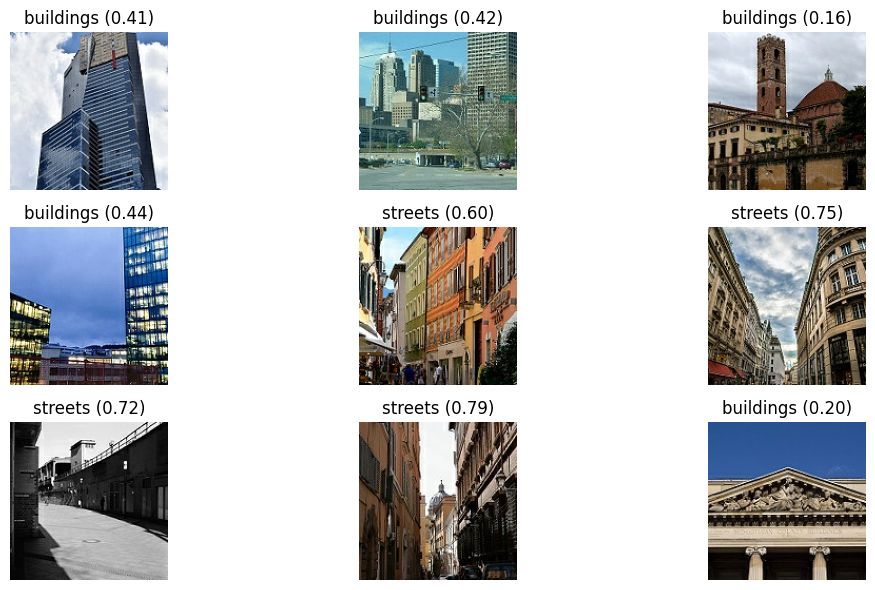

In [119]:
import matplotlib.pyplot as plt

# Load original RGB images for display
raw_pred_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/pred",
    labels=None,
    image_size=(IMG_H, IMG_W),
    batch_size=9,
    shuffle=False
)

for images in raw_pred_ds.take(1):
    imgs = images.numpy().astype("uint8")

plt.figure(figsize=(12,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[i])
    plt.title(f"{pred_labels[i]} ({pred_prob[i][0]:.2f})")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [120]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(image_path):
    img = load_img(image_path, target_size=(IMG_H, IMG_W))
    img_array = img_to_array(img) / 255.0
    img_array = tf.reshape(img_array, (1, IMG_H, IMG_W * 3))

    pred_prob = model.predict(img_array)[0][0]
    pred_class = 1 if pred_prob >= 0.5 else 0
    print(f"Predicted class: {class_names[pred_class]} (prob={pred_prob:.3f})")

# Example:
predict_image("/content/dataset/pred/pred/20083.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted class: streets (prob=0.731)
